In [ ]:
from google.colab import drive
drive.mount('/content/drive/MyDrive/DDP')

import zipfile
import pandas as pd

# ---- PATH TO YOUR ZIP FILE IN DRIVE ----
zip_path = "/content/drive/MyDrive/DDP/data_5L_new.zip"

# ---- UNZIP INTO A TEMP FOLDER ----
extract_dir = "/content/extracted_zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# ---- FIND THE CSV AUTOMATICALLY ----
import os

csv_file = None
for file in os.listdir(extract_dir):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_dir, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

# ---- LOAD INTO DATAFRAME ----
df = pd.read_csv(csv_file)

print("CSV loaded successfully!")
print(df.head())

MessageError: Error: credential propagation was unsuccessful

In [ ]:
def prepare_data(df):
    """Prepare data for modeling."""
    # Select relevant features for fraud detection
    feature_cols = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]

    # One-hot encode categorical variables
    categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                       'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Get all feature columns (original + encoded)
    all_features = [col for col in df_encoded.columns if col in feature_cols or
                   any(cat in col for cat in categorical_cols)]

    X = df_encoded[all_features].values
    y = df['fraud_label'].values
    sum_insured = df['sum_insured'].values

    return X, y, sum_insured, all_features

# ==================== COST CALCULATION FUNCTIONS ====================

def calculate_costs(sum_insured, y_true, y_pred):
    """
    Calculate instance-dependent costs for fraud detection.

    Cost structure:
    - FN (Missing fraud): Lose 90% of sum_insured (fraud payout)
    - FP (False accusation): Fixed £100 administrative + customer relation cost
    - TN (Correct rejection): £0
    - TP (Caught fraud): £0
    """
    costs = np.zeros(len(y_true))

    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 0:  # False Negative (missed fraud)
            costs[i] = sum_insured[i] * 0.90
        elif y_true[i] == 0 and y_pred[i] == 1:  # False Positive (false accusation)
            costs[i] = 100
        # True Positive and True Negative have 0 cost

    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive cost-sensitive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    total_cost = np.sum(costs)

    # Breakdown by error type
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    fn_cost = np.sum(costs[fn_mask])
    fp_cost = np.sum(costs[fp_mask])
    fn_count = np.sum(fn_mask)
    fp_count = np.sum(fp_mask)

    # Traditional metrics
    tn = np.sum((y_true == 0) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    results = {
        'total_cost': total_cost,
        'fn_cost': fn_cost,
        'fp_cost': fp_cost,
        'fn_count': fn_count,
        'fp_count': fp_count,
        'tp': tp,
        'tn': tn,
        'avg_cost_per_sample': total_cost / len(y_true)
    }

    # Calculate rates
    if tp + fn_count > 0:
        results['recall'] = tp / (tp + fn_count)
    else:
        results['recall'] = 0

    if tp + fp_count > 0:
        results['precision'] = tp / (tp + fp_count)
    else:
        results['precision'] = 0

    return results

In [ ]:
# ==================== ACTIVE LEARNING FRAMEWORK ====================
# Cost-Aware Active Learning for Fraud Detection

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# Use only Uncertainty Sampling. Adapt it for quarterly, and annualy  as in whatsapp.
class CostAwareActiveLearner:
    """
    Active Learning framework with cost-aware query strategies for fraud detection.

    Query Strategies:
    1. Uncertainty Sampling: Select samples where model is most uncertain
    2. Expected Cost Reduction: Select samples that would reduce cost the most
    3. Cost-Weighted Uncertainty: Combine uncertainty with instance cost
    4. Diversity Sampling: Ensure diverse samples are selected
    """

    def __init__(self, X_pool, y_pool, sum_insured_pool, X_test, y_test, sum_insured_test,
                 initial_labeled_size=1000, query_size=100, strategy='expected_cost_reduction'):
        """
        Initialize active learner.

        Parameters:
        -----------
        X_pool : array-like
            Unlabeled pool of samples
        y_pool : array-like
            True labels (hidden, used for simulation)
        sum_insured_pool : array-like
            Sum insured values for pool samples
        X_test : array-like
            Test set for evaluation
        y_test : array-like
            Test labels
        sum_insured_test : array-like
            Sum insured values for test samples
        initial_labeled_size : int
            Initial number of labeled samples
        query_size : int
            Number of samples to query per iteration
        strategy : str
            Query strategy: 'uncertainty', 'expected_cost_reduction', 'cost_weighted_uncertainty', 'diversity'
        """
        self.X_pool = X_pool
        self.y_pool = y_pool
        self.sum_insured_pool = sum_insured_pool
        self.X_test = X_test
        self.y_test = y_test
        self.sum_insured_test = sum_insured_test
        self.query_size = query_size
        self.strategy = strategy

        # Initialize labeled and unlabeled sets
        np.random.seed(42)
        initial_indices = np.random.choice(len(X_pool), initial_labeled_size, replace=False)

        self.labeled_indices = set(initial_indices)
        self.unlabeled_indices = set(range(len(X_pool))) - self.labeled_indices

        # History tracking
        self.cost_history = []
        self.model_history = []
        self.query_history = []
        self.labeled_count_history = []

        # Scaler
        self.scaler = StandardScaler()

    def get_labeled_data(self):
        """Get current labeled dataset."""
        labeled_idx = list(self.labeled_indices)
        X_labeled = self.X_pool[labeled_idx]
        y_labeled = self.y_pool[labeled_idx]
        sum_labeled = self.sum_insured_pool[labeled_idx]
        return X_labeled, y_labeled, sum_labeled, labeled_idx

    def train_model(self, X_train, y_train, sum_train):
        """Train cost-sensitive XGBoost model."""
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)

        # Calculate scale_pos_weight
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1

        # Train XGBoost
        model = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='logloss'
        )
        model.fit(X_train_scaled, y_train)

        return model

    def find_optimal_threshold(self, model, X_train, y_train, sum_train):
        """Find optimal threshold that minimizes cost."""
        X_train_scaled = self.scaler.transform(X_train)
        y_proba = model.predict_proba(X_train_scaled)[:, 1]

        thresholds = np.linspace(0.05, 0.95, 100)
        best_cost = float('inf')
        best_threshold = 0.5

        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            cost = np.sum(calculate_costs(sum_train, y_train, y_pred))

            if cost < best_cost:
                best_cost = cost
                best_threshold = threshold

        return best_threshold

    def evaluate_model(self, model, threshold):
        """Evaluate model on test set."""
        X_test_scaled = self.scaler.transform(self.X_test)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        results = evaluate_cost_sensitive(self.y_test, y_pred, self.sum_insured_test)
        return results, y_pred

    def uncertainty_sampling(self, model, unlabeled_idx):
        """Select samples with highest prediction uncertainty."""
        unlabeled_list = list(unlabeled_idx)
        X_unlabeled = self.X_pool[unlabeled_list]
        X_unlabeled_scaled = self.scaler.transform(X_unlabeled)

        # Get prediction probabilities
        y_proba = model.predict_proba(X_unlabeled_scaled)[:, 1]

        # Calculate uncertainty (entropy)
        # For binary classification: entropy = -p*log(p) - (1-p)*log(1-p)
        uncertainties = -y_proba * np.log(y_proba + 1e-10) - (1 - y_proba) * np.log(1 - y_proba + 1e-10)

        # Select top-k most uncertain
        top_k_indices = np.argsort(uncertainties)[-self.query_size:][::-1]
        selected_indices = [unlabeled_list[i] for i in top_k_indices]

        return selected_indices

    def expected_cost_reduction(self, model, unlabeled_idx):
        """
        Select samples that would reduce expected cost the most.
        For each unlabeled sample, estimate cost reduction if we knew its label.
        """
        unlabeled_list = list(unlabeled_idx)
        X_unlabeled = self.X_pool[unlabeled_list]
        X_unlabeled_scaled = self.scaler.transform(X_unlabeled)
        sum_unlabeled = self.sum_insured_pool[unlabeled_list]

        # Get current predictions
        y_proba = model.predict_proba(X_unlabeled_scaled)[:, 1]
        y_pred_current = (y_proba >= 0.5).astype(int)

        # Calculate expected cost reduction for each sample
        cost_reductions = []

        for i, idx in enumerate(unlabeled_list):
            # Current prediction cost
            # We simulate by assuming current prediction
            current_cost = 0
            if y_pred_current[i] == 0:  # Predicted as legitimate
                # If it's actually fraud (FN), cost = sum_insured * 0.9
                # Expected cost = P(fraud) * FN_cost
                current_cost = y_proba[i] * sum_unlabeled[i] * 0.9
            else:  # Predicted as fraud
                # If it's actually legitimate (FP), cost = 100
                # Expected cost = P(legitimate) * FP_cost
                current_cost = (1 - y_proba[i]) * 100

            # If we knew the true label, we could make perfect prediction
            # Cost would be 0 (perfect prediction)
            # Cost reduction = current_cost - 0 = current_cost

            # But we don't know the label, so we use expected value
            # Expected cost if we query and label this sample
            # = P(fraud) * cost_if_fraud + P(legitimate) * cost_if_legitimate
            # If fraud: we predict fraud, cost = 0
            # If legitimate: we predict legitimate, cost = 0
            # So expected cost after labeling = 0

            # However, we need to consider that labeling has value
            # The value is the reduction in uncertainty-weighted cost
            cost_reduction = current_cost

            # Weight by uncertainty (more uncertain = more valuable to label)
            uncertainty = -y_proba[i] * np.log(y_proba[i] + 1e-10) - (1 - y_proba[i]) * np.log(1 - y_proba[i] + 1e-10)
            cost_reduction *= (1 + uncertainty)  # Boost uncertain samples

            cost_reductions.append(cost_reduction)

        # Select top-k samples with highest cost reduction potential
        cost_reductions = np.array(cost_reductions)
        top_k_indices = np.argsort(cost_reductions)[-self.query_size:][::-1]
        selected_indices = [unlabeled_list[i] for i in top_k_indices]

        return selected_indices

    def cost_weighted_uncertainty(self, model, unlabeled_idx):
        """Combine uncertainty with instance cost (sum_insured)."""
        unlabeled_list = list(unlabeled_idx)
        X_unlabeled = self.X_pool[unlabeled_list]
        X_unlabeled_scaled = self.scaler.transform(X_unlabeled)
        sum_unlabeled = self.sum_insured_pool[unlabeled_list]

        # Get prediction probabilities
        y_proba = model.predict_proba(X_unlabeled_scaled)[:, 1]

        # Calculate uncertainty
        uncertainties = -y_proba * np.log(y_proba + 1e-10) - (1 - y_proba) * np.log(1 - y_proba + 1e-10)

        # Weight by potential cost (sum_insured)
        # Higher sum_insured = higher cost if we miss fraud
        normalized_sum = (sum_unlabeled - sum_unlabeled.min()) / (sum_unlabeled.max() - sum_unlabeled.min() + 1e-10)

        # Combined score: uncertainty * cost_weight
        scores = uncertainties * (1 + normalized_sum * 2)  # Boost high-value samples

        # Select top-k
        top_k_indices = np.argsort(scores)[-self.query_size:][::-1]
        selected_indices = [unlabeled_list[i] for i in top_k_indices]

        return selected_indices

    def diversity_sampling(self, model, unlabeled_idx, alpha=0.5):
        """
        Select diverse samples to avoid redundancy.
        Combines uncertainty with diversity (distance from labeled set).
        """
        unlabeled_list = list(unlabeled_idx)
        X_unlabeled = self.X_pool[unlabeled_list]
        X_unlabeled_scaled = self.scaler.transform(X_unlabeled)

        # Get labeled samples
        X_labeled, _, _, _ = self.get_labeled_data()
        X_labeled_scaled = self.scaler.transform(X_labeled)

        # Calculate uncertainty
        y_proba = model.predict_proba(X_unlabeled_scaled)[:, 1]
        uncertainties = -y_proba * np.log(y_proba + 1e-10) - (1 - y_proba) * np.log(1 - y_proba + 1e-10)

        # Calculate diversity (minimum distance to labeled set)
        from scipy.spatial.distance import cdist
        distances = cdist(X_unlabeled_scaled, X_labeled_scaled, metric='euclidean')
        min_distances = distances.min(axis=1)

        # Normalize
        uncertainties_norm = (uncertainties - uncertainties.min()) / (uncertainties.max() - uncertainties.min() + 1e-10)
        distances_norm = (min_distances - min_distances.min()) / (min_distances.max() - min_distances.min() + 1e-10)

        # Combined score
        scores = alpha * uncertainties_norm + (1 - alpha) * distances_norm

        # Select top-k
        top_k_indices = np.argsort(scores)[-self.query_size:][::-1]
        selected_indices = [unlabeled_list[i] for i in top_k_indices]

        return selected_indices

    def query_samples(self, model):
        """Query samples based on selected strategy."""
        if self.strategy == 'uncertainty':
            return self.uncertainty_sampling(model, self.unlabeled_indices)
        elif self.strategy == 'expected_cost_reduction':
            return self.expected_cost_reduction(model, self.unlabeled_indices)
        elif self.strategy == 'cost_weighted_uncertainty':
            return self.cost_weighted_uncertainty(model, self.unlabeled_indices)
        elif self.strategy == 'diversity':
            return self.diversity_sampling(model, self.unlabeled_indices)
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

    def run_active_learning(self, n_iterations=20):
        """
        Run active learning loop.

        Parameters:
        -----------
        n_iterations : int
            Number of active learning iterations
        """
        print(f"\n{'='*80}")
        print(f"ACTIVE LEARNING: {self.strategy.upper()}")
        print(f"{'='*80}")
        print(f"Initial labeled samples: {len(self.labeled_indices)}")
        print(f"Unlabeled pool size: {len(self.unlabeled_indices)}")
        print(f"Query size per iteration: {self.query_size}")
        print(f"Total iterations: {n_iterations}\n")

        for iteration in range(n_iterations):
            # Get current labeled data
            X_labeled, y_labeled, sum_labeled, _ = self.get_labeled_data()

            # Train model
            model = self.train_model(X_labeled, y_labeled, sum_labeled)

            # Find optimal threshold
            threshold = self.find_optimal_threshold(model, X_labeled, y_labeled, sum_labeled)

            # Evaluate on test set
            results, y_pred = self.evaluate_model(model, threshold)

            # Store history
            self.cost_history.append(results['total_cost'])
            self.model_history.append(model)
            self.labeled_count_history.append(len(self.labeled_indices))

            # Print progress
            print(f"Iteration {iteration+1}/{n_iterations}:")
            print(f"  Labeled samples: {len(self.labeled_indices)}")
            print(f"  Test cost: £{results['total_cost']:,.0f}")
            print(f"  FN cost: £{results['fn_cost']:,.0f} ({results['fn_count']} FNs)")
            print(f"  FP cost: £{results['fp_cost']:,.0f} ({results['fp_count']} FPs)")
            print(f"  Recall: {results['recall']:.3f}, Precision: {results['precision']:.3f}")

            # Check if we have enough unlabeled samples
            if len(self.unlabeled_indices) < self.query_size:
                print(f"\nNot enough unlabeled samples. Stopping at iteration {iteration+1}")
                break

            # Query new samples
            selected_indices = self.query_samples(model)
            self.query_history.append(selected_indices)

            # Add to labeled set
            self.labeled_indices.update(selected_indices)
            self.unlabeled_indices -= set(selected_indices)

            print(f"  Queried {len(selected_indices)} samples\n")

        print(f"\n{'='*80}")
        print("ACTIVE LEARNING COMPLETE")
        print(f"{'='*80}")

        return self.cost_history, self.model_history

In [ ]:
# ==================== SINGLE STRATEGY EXAMPLE ====================
# To run a single strategy instead of comparing all:

# Prepare data
X, y, sum_insured, feature_names = prepare_data(df)
X_temp, X_test, y_temp, y_test, sum_temp, sum_test = train_test_split(
    X, y, sum_insured, test_size=0.2, random_state=42, stratify=y
)

# Create pool
pool_indices = np.random.choice(len(X_temp), 20000, replace=False)
X_pool = X_temp[pool_indices]
y_pool = y_temp[pool_indices]
sum_pool = sum_temp[pool_indices]

# Run active learning with expected cost reduction strategy
learner = CostAwareActiveLearner(
    X_pool=X_pool,
    y_pool=y_pool,
    sum_insured_pool=sum_pool,
    X_test=X_test,
    y_test=y_test,
    sum_insured_test=sum_test,
    initial_labeled_size=1000,
    query_size=500,
    strategy='expected_cost_reduction'  # Best for cost-sensitive problems
)

cost_history, model_history = learner.run_active_learning(n_iterations=10)


ACTIVE LEARNING: EXPECTED_COST_REDUCTION
Initial labeled samples: 1000
Unlabeled pool size: 19000
Query size per iteration: 500
Total iterations: 10

Iteration 1/10:
  Labeled samples: 1000
  Test cost: £214,143,000
  FN cost: £214,065,000 (629 FNs)
  FP cost: £78,000 (780 FPs)
  Recall: 0.875, Precision: 0.849
  Queried 500 samples

Iteration 2/10:
  Labeled samples: 1500
  Test cost: £102,619,100
  FN cost: £102,555,000 (287 FNs)
  FP cost: £64,100 (641 FPs)
  Recall: 0.943, Precision: 0.881
  Queried 500 samples

Iteration 3/10:
  Labeled samples: 2000
  Test cost: £61,215,300
  FN cost: £61,155,000 (194 FNs)
  FP cost: £60,300 (603 FPs)
  Recall: 0.961, Precision: 0.889
  Queried 500 samples

Iteration 4/10:
  Labeled samples: 2500
  Test cost: £84,248,400
  FN cost: £84,195,000 (246 FNs)
  FP cost: £53,400 (534 FPs)
  Recall: 0.951, Precision: 0.900
  Queried 500 samples

Iteration 5/10:
  Labeled samples: 3000
  Test cost: £93,601,100
  FN cost: £93,555,000 (282 FNs)
  FP cost: 

In [ ]:
def compare_active_learning_strategies(df, test_size=0.2, pool_size=50000,
                                       initial_labeled=1000, query_size=500, n_iterations=15):
    """
    Compare different active learning strategies.

    Parameters:
    -----------
    df : DataFrame
        Full dataset with features and labels
    test_size : float
        Proportion of data for test set
    pool_size : int
        Size of unlabeled pool for active learning
    initial_labeled : int
        Initial number of labeled samples
    query_size : int
        Number of samples to query per iteration
    n_iterations : int
        Number of active learning iterations
    """
    print("\n" + "="*80)
    print("PREPARING DATA FOR ACTIVE LEARNING")
    print("="*80)

    # Prepare data
    X, y, sum_insured, feature_names = prepare_data(df)

    # Split: test set (20%), pool (for active learning), rest (unused)
    X_temp, X_test, y_temp, y_test, sum_temp, sum_test = train_test_split(
        X, y, sum_insured, test_size=test_size, random_state=42, stratify=y
    )

    # Create pool from remaining data
    pool_indices = np.random.choice(len(X_temp), pool_size, replace=False)
    X_pool = X_temp[pool_indices]
    y_pool = y_temp[pool_indices]
    sum_pool = sum_temp[pool_indices]

    print(f"Test set size: {len(X_test)}")
    print(f"Pool size: {len(X_pool)}")
    print(f"Fraud rate (test): {y_test.mean()*100:.2f}%")
    print(f"Fraud rate (pool): {y_pool.mean()*100:.2f}%")

    # Strategies to compare
    # strategies = ['uncertainty', 'expected_cost_reduction', 'cost_weighted_uncertainty', 'diversity']
    strategies = ['uncertainty']

    results = {}

    for strategy in strategies:
        print(f"\n{'='*80}")
        print(f"Running strategy: {strategy}")
        print(f"{'='*80}")

        learner = CostAwareActiveLearner(
            X_pool=X_pool,
            y_pool=y_pool,
            sum_insured_pool=sum_pool,
            X_test=X_test,
            y_test=y_test,
            sum_insured_test=sum_test,
            initial_labeled_size=initial_labeled,
            query_size=query_size,
            strategy=strategy
        )

        cost_history, model_history = learner.run_active_learning(n_iterations=n_iterations)
        results[strategy] = {
            'cost_history': cost_history,
            'model_history': model_history,
            'labeled_count_history': learner.labeled_count_history
        }

    # Visualization
    plt.figure(figsize=(16, 10))

    # Plot 1: Cost over iterations
    plt.subplot(2, 2, 1)
    for strategy in strategies:
        plt.plot(results[strategy]['labeled_count_history'],
                results[strategy]['cost_history'],
                marker='o', label=strategy.replace('_', ' ').title(), linewidth=2)
    plt.xlabel('Number of Labeled Samples', fontsize=11)
    plt.ylabel('Total Cost (£)', fontsize=11)
    plt.title('Cost Reduction Over Active Learning Iterations', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot 2: Cost reduction percentage
    plt.subplot(2, 2, 2)
    for strategy in strategies:
        cost_history = np.array(results[strategy]['cost_history'])
        initial_cost = cost_history[0]
        cost_reduction = ((initial_cost - cost_history) / initial_cost) * 100
        plt.plot(results[strategy]['labeled_count_history'],
                cost_reduction,
                marker='o', label=strategy.replace('_', ' ').title(), linewidth=2)
    plt.xlabel('Number of Labeled Samples', fontsize=11)
    plt.ylabel('Cost Reduction (%)', fontsize=11)
    plt.title('Percentage Cost Reduction', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot 3: Final cost comparison
    plt.subplot(2, 2, 3)
    final_costs = [results[s]['cost_history'][-1] for s in strategies]
    colors = ['#2ecc71' if c == min(final_costs) else '#e74c3c' if c == max(final_costs) else '#3498db'
              for c in final_costs]
    plt.barh([s.replace('_', ' ').title() for s in strategies], final_costs, color=colors)
    plt.xlabel('Final Total Cost (£)', fontsize=11)
    plt.title('Final Cost Comparison', fontsize=12, fontweight='bold')
    for i, v in enumerate(final_costs):
        plt.text(v, i, f' £{v:,.0f}', va='center', fontsize=9)
    plt.gca().invert_yaxis()

    # Plot 4: Learning efficiency (cost per labeled sample)
    plt.subplot(2, 2, 4)
    for strategy in strategies:
        labeled_counts = np.array(results[strategy]['labeled_count_history'])
        costs = np.array(results[strategy]['cost_history'])
        efficiency = costs / labeled_counts  # Cost per labeled sample
        plt.plot(labeled_counts, efficiency,
                marker='o', label=strategy.replace('_', ' ').title(), linewidth=2)
    plt.xlabel('Number of Labeled Samples', fontsize=11)
    plt.ylabel('Cost per Labeled Sample (£)', fontsize=11)
    plt.title('Learning Efficiency', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.suptitle('Active Learning Strategy Comparison for Cost-Sensitive Fraud Detection',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n" + "="*80)
    print("ACTIVE LEARNING COMPARISON SUMMARY")
    print("="*80)

    summary_data = {
        'Strategy': [s.replace('_', ' ').title() for s in strategies],
        'Initial Cost (£)': [results[s]['cost_history'][0] for s in strategies],
        'Final Cost (£)': [results[s]['cost_history'][-1] for s in strategies],
        'Cost Reduction (£)': [results[s]['cost_history'][0] - results[s]['cost_history'][-1]
                              for s in strategies],
        'Cost Reduction (%)': [((results[s]['cost_history'][0] - results[s]['cost_history'][-1]) /
                               results[s]['cost_history'][0] * 100) for s in strategies],
        'Final Labeled Samples': [results[s]['labeled_count_history'][-1] for s in strategies]
    }

    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('Final Cost (£)')
    print("\n" + summary_df.to_string(index=False))

    return results, summary_df


PREPARING DATA FOR ACTIVE LEARNING
Test set size: 150000
Pool size: 350000
Fraud rate (test): 5.03%
Fraud rate (pool): 5.03%

Running strategy: uncertainty

ACTIVE LEARNING: UNCERTAINTY
Initial labeled samples: 1000
Unlabeled pool size: 349000
Query size per iteration: 1000
Total iterations: 350

Iteration 1/350:
  Labeled samples: 1000
  Test cost: £84,775,700
  FN cost: £84,465,000 (263 FNs)
  FP cost: £310,700 (3107 FPs)
  Recall: 0.965, Precision: 0.701
  Queried 1000 samples

Iteration 2/350:
  Labeled samples: 2000
  Test cost: £252,064,300
  FN cost: £252,000,000 (727 FNs)
  FP cost: £64,300 (643 FPs)
  Recall: 0.904, Precision: 0.914
  Queried 1000 samples

Iteration 3/350:
  Labeled samples: 3000
  Test cost: £209,171,300
  FN cost: £209,115,000 (617 FNs)
  FP cost: £56,300 (563 FPs)
  Recall: 0.918, Precision: 0.925
  Queried 1000 samples

Iteration 4/350:
  Labeled samples: 4000
  Test cost: £68,070,900
  FN cost: £67,995,000 (204 FNs)
  FP cost: £75,900 (759 FPs)
  Recall:

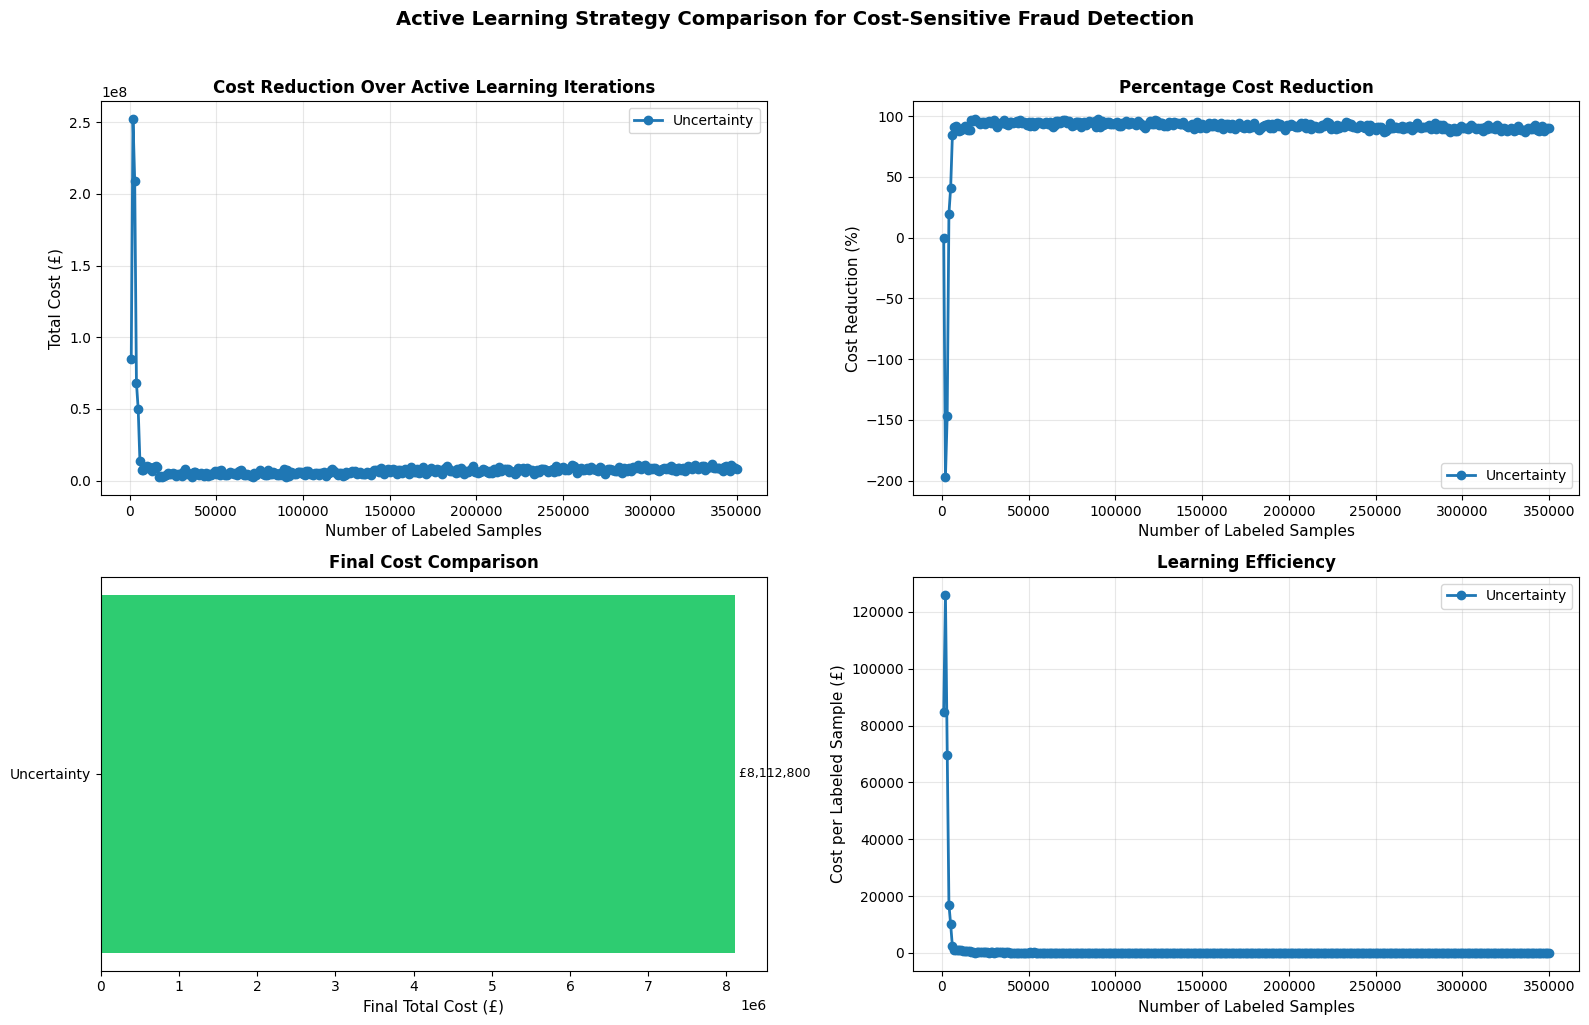


ACTIVE LEARNING COMPARISON SUMMARY

   Strategy  Initial Cost (£)  Final Cost (£)  Cost Reduction (£)  Cost Reduction (%)  Final Labeled Samples
Uncertainty        84775700.0       8112800.0          76662900.0           90.430277                 350000


In [ ]:
# ==================== RUN ACTIVE LEARNING COMPARISON ====================
# This will compare all active learning strategies

# Note: This may take a while to run (15-30 minutes depending on your hardware)
# Adjust parameters for faster execution:
# - Reduce pool_size (e.g., 20000 instead of 50000)
# - Reduce n_iterations (e.g., 10 instead of 15)
# - Reduce query_size (e.g., 250 instead of 500)

# Uncomment to run:
results, summary_df = compare_active_learning_strategies(
    df=df,
    test_size=0.3,
    pool_size=350000,         # Size of unlabeled pool
    initial_labeled=1000,     # Start with 1000 labeled samples
    query_size=1000,          # Query 1000 samples per iteration
    n_iterations=350
)

In [ ]:
summary_df

,Strategy,Initial Cost (£),Final Cost (£),Cost Reduction (£),Cost Reduction (%),Final Labeled Samples
0,Uncertainty,84775700.0,8112800.0,76662900.0,90.430277,350000


In [ ]:
import joblib
import os

def save_best_active_learning_model(results, summary_df, output_dir='models'):
    """
    Identifies the best strategy from summary_df, extracts the final model
    from results, and saves it.
    """
    # 1. Identify the best strategy (lowest Final Cost)
    best_row = summary_df.loc[summary_df['Final Cost (£)'].idxmin()]
    best_strategy_name = best_row['Strategy'].lower().replace(' ', '_')
    min_cost = best_row['Final Cost (£)']

    print(f"\n{'='*60}")
    print(f"SAVING BEST MODEL")
    print(f"{'='*60}")
    print(f"Best Strategy: {best_strategy_name.replace('_', ' ').title()}")
    print(f"Final Cost: £{min_cost:,.2f}")

    # 2. Extract the final model from the results dictionary
    # We access the 'model_history' of the best strategy and take the last element [-1]
    # Note: This assumes model_history stores the actual model objects.
    try:
        final_model = results[best_strategy_name]['model_history'][-1]
    except KeyError:
        # Fallback if strategy naming conventions differ slightly
        keys = list(results.keys())
        # Try to find the key that matches the best strategy name
        matching_key = next((k for k in keys if k in best_strategy_name or best_strategy_name in k), None)
        if matching_key:
            final_model = results[matching_key]['model_history'][-1]
        else:
            print("Error: Could not map summary strategy name to results dictionary keys.")
            return

    # 3. Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 4. Save the model
    filename = f"models\\model_strategy_{best_strategy_name}.joblib"
    filepath = os.path.join(output_dir, filename)

    joblib.dump(final_model, filepath)

    print(f"✔ Model saved successfully to: {filepath}")
    print(f"  (You can load it later using: model = joblib.load('{filepath}'))")

    return filepath

# ==================== EXECUTE SAVE ====================
# Run this using the variables returned from your previous function
saved_model_path = save_best_active_learning_model(results, summary_df)

NameError: name 'results' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


# ==================== RULE-BASED SYSTEM ====================

def apply_fraud_rules(df):
    """
    UK Industry-standard fraud detection rules.
    Returns flagged indices based on rule violations.
    """
    flags = pd.Series(False, index=df.index)

    # Calculate derived metrics
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    # RULE 1: High claim ratio + early policyholder (no previous insurance)
    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)

    # RULE 2: Accidental damage + unoccupied + early claim
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)

    # RULE 3: High claim frequency
    flags |= (df['no_of_claims_5yr'] >= 3)

    # RULE 4: Unoccupied + business use + claims
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)

    # RULE 5: Coverage inflation
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)

    # RULE 6: High additional coverage
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)

    # RULE 7: Payment issues + claims
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)

    # RULE 8: Short-term letting + claims
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)

    return flags


# ==================== HELPER FUNCTIONS ====================

def prepare_features(df, categorical_cols=None):
    """Prepare features with one-hot encoding."""
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                          'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Exclude target and metadata columns
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

    return df_encoded[feature_cols]


def calculate_costs(sum_insured, y_true, y_pred):
    """Calculate instance-dependent costs."""
    costs = np.zeros(len(y_true))
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 0:  # FN
            costs[i] = sum_insured[i] * 0.90
        elif y_true[i] == 0 and y_pred[i] == 1:  # FP
            costs[i] = 100
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn_count = np.sum(fn_mask)
    fp_count = np.sum(fp_mask)

    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    precision = tp / (tp + fp_count) if (tp + fp_count) > 0 else 0

    return {
        'total_cost': np.sum(costs),
        'fn_cost': np.sum(costs[fn_mask]),
        'fp_cost': np.sum(costs[fp_mask]),
        'fn_count': fn_count,
        'fp_count': fp_count,
        'tp': tp, 'tn': tn,
        'recall': recall,
        'precision': precision
    }


def find_optimal_threshold(model, X, y, sum_insured):
    """Find cost-minimizing threshold."""
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (proba >= threshold).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_threshold = threshold

    return best_threshold


# ==================== ACTIVE LEARNING PIPELINE ====================

class RealWorldActiveLearning:
    """
    Active Learning as per transcript workflow:
    1. Rule-based filtering on initial customers
    2. Train ML model on investigated (flagged) cases
    3. Monthly/Quarterly: Test on new customers, query uncertain cases
    4. Retrain with expanded labeled set
    5. Track performance improvement over time
    """

    def __init__(self, model_type='xgboost'):
        self.model_type = model_type
        self.model = None
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': [], 'y': [], 'sum_insured': []}
        self.performance_history = []
        self.feature_names = None

    def initialize_model(self):
        """Initialize ML model."""
        if self.model_type == 'xgboost':
            self.model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                scale_pos_weight=5,  # Handle imbalance
                random_state=42,
                eval_metric='logloss'
            )
        else:
            self.model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                class_weight='balanced',
                random_state=42
            )

    def rule_based_filtering(self, df_universe, n_initial=10000):
        """
        Step 1: Take initial customers from universe, apply rules, flag suspicious.
        Returns: flagged indices from universe
        """
        print("="*80)
        print("STEP 1: RULE-BASED FILTERING")
        print("="*80)

        # Sample initial customers
        initial_customers = df_universe.sample(n=min(n_initial, len(df_universe)), random_state=42)

        # Apply fraud rules
        suspicious_flags = apply_fraud_rules(initial_customers)
        flagged_indices = initial_customers[suspicious_flags].index

        print(f"Initial customers: {len(initial_customers)}")
        print(f"Flagged as suspicious: {len(flagged_indices)} ({len(flagged_indices)/len(initial_customers)*100:.1f}%)")

        return flagged_indices, initial_customers.index

    def investigate_and_train(self, df_universe, flagged_indices):
        """
        Step 2: Investigate flagged cases (get true labels from universe).
        Train initial ML model on investigated cases.
        """
        print("\n" + "="*80)
        print("STEP 2: INVESTIGATION & INITIAL MODEL TRAINING")
        print("="*80)

        # Get investigated cases with true labels
        investigated = df_universe.loc[flagged_indices]

        # Prepare features
        X_features = prepare_features(investigated.copy())
        self.feature_names = X_features.columns.tolist()
        X = X_features.values
        y = investigated['fraud_label'].values
        sum_insured = investigated['sum_insured'].values

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Store labeled data
        self.labeled_data['X'] = X_scaled.copy()
        self.labeled_data['y'] = y.copy()
        self.labeled_data['sum_insured'] = sum_insured.copy()

        # Train model
        self.initialize_model()
        self.model.fit(X_scaled, y)

        # Find optimal threshold
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, sum_insured)

        print(f"Investigated cases: {len(flagged_indices)}")
        print(f"Fraud cases found: {y.sum()} ({y.mean()*100:.1f}%)")
        print(f"Initial model trained with {len(X)} samples")
        print(f"Optimal threshold: {self.threshold:.3f}")

        return X_scaled, y, sum_insured

    def test_model(self, df_test):
        """
        Step 3: Test model on new customers.
        Returns predictions and evaluation metrics.
        """
        # Prepare test features
        X_features = prepare_features(df_test.copy())
        # Align features with training
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X_test = X_features.values
        X_test_scaled = self.scaler.transform(X_test)
        y_test = df_test['fraud_label'].values
        sum_test = df_test['sum_insured'].values

        # Predict
        y_proba = self.model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_proba >= self.threshold).astype(int)

        # Evaluate
        results = evaluate_cost_sensitive(y_test, y_pred, sum_test)
        results['y_proba'] = y_proba

        return results

    def query_uncertain_cases(self, df_new, uncertainty_range=(0.2, 0.8), top_n=None):
        """
        FIXED: Query uncertain cases + high-confidence positives for balanced learning.
        """
        # Prepare features
        X_features = prepare_features(df_new.copy())
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X = X_features.values
        X_scaled = self.scaler.transform(X)

        # Get prediction probabilities
        y_proba = self.model.predict_proba(X_scaled)[:, 1]

        # Strategy 1: Uncertain cases (0.2-0.8)
        uncertain_mask = (y_proba >= uncertainty_range[0]) & (y_proba <= uncertainty_range[1])

        # Strategy 2: High-confidence frauds (>0.8) - verify these too
        high_conf_fraud = y_proba > 0.8

        # Strategy 3: Some low-confidence legitimate (<0.2) for balance
        low_conf_legit = y_proba < 0.2

        # Combine: 70% uncertain, 20% high-conf fraud, 10% low-conf legit
        uncertain_idx = df_new[uncertain_mask].index.tolist()
        high_fraud_idx = df_new[high_conf_fraud].index.tolist()
        low_legit_idx = df_new[low_conf_legit].index.tolist()

        if top_n:
            n_uncertain = int(top_n * 0.7)
            n_high = int(top_n * 0.2)
            n_low = top_n - n_uncertain - n_high

            # Sample with cost-weighting
            selected = []

            if len(uncertain_idx) > 0:
                n_sample = min(n_uncertain, len(uncertain_idx))
                weights = df_new.loc[uncertain_idx, 'sum_insured'].values
                weights = weights / weights.sum()
                selected.extend(np.random.choice(uncertain_idx, n_sample, replace=False, p=weights))

            if len(high_fraud_idx) > 0:
                n_sample = min(n_high, len(high_fraud_idx))
                selected.extend(np.random.choice(high_fraud_idx, n_sample, replace=False))

            if len(low_legit_idx) > 0:
                n_sample = min(n_low, len(low_legit_idx))
                selected.extend(np.random.choice(low_legit_idx, n_sample, replace=False))

            uncertain_indices = selected
        else:
            uncertain_indices = uncertain_idx + high_fraud_idx[:20] + low_legit_idx[:10]

        return uncertain_indices

    def retrain_with_new_labels(self, df_universe, new_labeled_indices):
        """
        FIXED: Add new labels but maintain stable threshold.
        """
        # Get new labeled data
        new_data = df_universe.loc[new_labeled_indices]
        X_features = prepare_features(new_data.copy())
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X_new = X_features.values
        X_new_scaled = self.scaler.transform(X_new)
        y_new = new_data['fraud_label'].values
        sum_new = new_data['sum_insured'].values

        # Append to labeled data
        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new_scaled])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], sum_new])

        # Retrain model
        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])

        # FIXED: Only update threshold if significant improvement (>5% cost reduction)
        old_threshold = self.threshold
        new_threshold = find_optimal_threshold(
            self.model,
            self.labeled_data['X'],
            self.labeled_data['y'],
            self.labeled_data['sum_insured']
        )

        # Test both thresholds on training data
        y_proba = self.model.predict_proba(self.labeled_data['X'])[:, 1]

        cost_old = np.sum(calculate_costs(
            self.labeled_data['sum_insured'],
            self.labeled_data['y'],
            (y_proba >= old_threshold).astype(int)
        ))

        cost_new = np.sum(calculate_costs(
            self.labeled_data['sum_insured'],
            self.labeled_data['y'],
            (y_proba >= new_threshold).astype(int)
        ))

        # Only update if >5% improvement
        if cost_new < cost_old * 0.95:
            self.threshold = new_threshold

        return len(self.labeled_data['y'])


# ==================== COMPLETE WORKFLOW ====================

def run_active_learning_workflow(df_universe, n_test=5000, n_months=6, monthly_customers=500):
    """
    Complete Active Learning workflow as per transcript:

    1. Rule-based filtering on 10K initial customers
    2. Train ML model on flagged cases (~2K investigated)
    3. Test on 5K new customers (baseline performance)
    4. Monthly loop (6 months):
       - New customers arrive (500/month)
       - Test model, query uncertain cases
       - Investigate and add to training
       - Retrain model
    5. Final test on 5K customers (show improvement)
    """

    print("\n" + "="*100)
    print(" "*30 + "ACTIVE LEARNING WORKFLOW")
    print("="*100)

    al = RealWorldActiveLearning(model_type='xgboost')

    # Track used indices
    used_indices = set()

    # ==================== STEP 1 & 2: RULE-BASED + INITIAL TRAINING ====================
    flagged_idx, initial_idx = al.rule_based_filtering(df_universe, n_initial=10000)
    used_indices.update(initial_idx)

    X_train, y_train, sum_train = al.investigate_and_train(df_universe, flagged_idx)

    # ==================== STEP 3: INITIAL TEST (BASELINE) ====================
    print("\n" + "="*80)
    print("STEP 3: BASELINE TEST (Before Active Learning)")
    print("="*80)

    available_test = df_universe.drop(index=used_indices)
    test_baseline = available_test.sample(n=min(n_test, len(available_test)), random_state=42)
    used_indices.update(test_baseline.index)

    results_baseline = al.test_model(test_baseline)

    print(f"Test samples: {len(test_baseline)}")
    print(f"Total Cost: £{results_baseline['total_cost']:,.0f}")
    print(f"Recall: {results_baseline['recall']*100:.1f}%")
    print(f"Precision: {results_baseline['precision']*100:.1f}%")

    al.performance_history.append({
        'iteration': 0,
        'month': 'Baseline',
        'labeled_count': len(al.labeled_data['y']),
        **results_baseline
    })

    # ==================== STEP 4: MONTHLY ACTIVE LEARNING LOOP ====================
    print("\n" + "="*80)
    print("STEP 4: ACTIVE LEARNING - MONTHLY ITERATIONS")
    print("="*80)

    # Fixed test set for consistent monthly evaluation
    available_monthly_test = df_universe.drop(index=used_indices)
    monthly_test_set = available_monthly_test.sample(n=min(1000, len(available_monthly_test)), random_state=999)
    used_indices.update(monthly_test_set.index)

    for month in range(1, n_months + 1):
        print(f"\n--- Month {month} ---")

        # New customers arrive
        available = df_universe.drop(index=used_indices)
        if len(available) < monthly_customers:
            print(f"Insufficient data remaining. Stopping at month {month-1}.")
            break

        new_customers = available.sample(n=monthly_customers, random_state=42+month)
        used_indices.update(new_customers.index)

        # Query uncertain cases (70% uncertain, 20% high-conf, 10% low-conf)
        uncertain_idx = al.query_uncertain_cases(new_customers, uncertainty_range=(0.2, 0.8), top_n=100)

        print(f"New customers: {len(new_customers)}")
        print(f"Cases queried for investigation: {len(uncertain_idx)}")

        # Investigate and retrain
        if len(uncertain_idx) > 0:
            new_labeled_count = al.retrain_with_new_labels(df_universe, uncertain_idx)
            print(f"Total labeled data: {new_labeled_count}")
            print(f"Threshold: {al.threshold:.3f}")

        # FIXED: Test on consistent held-out test set (not remaining customers)
        results_month = al.test_model(monthly_test_set)
        print(f"Monthly test cost (fixed test set): £{results_month['total_cost']:,.0f}")

        al.performance_history.append({
            'iteration': month,
            'month': f'Month {month}',
            'labeled_count': len(al.labeled_data['y']),
            **results_month
        })

    # ==================== STEP 5: FINAL TEST (SHOW IMPROVEMENT) ====================
    print("\n" + "="*80)
    print("STEP 5: FINAL TEST (After Active Learning)")
    print("="*80)

    available_final = df_universe.drop(index=used_indices)
    test_final = available_final.sample(n=min(n_test, len(available_final)), random_state=99)

    results_final = al.test_model(test_final)

    print(f"Test samples: {len(test_final)}")
    print(f"Total Cost: £{results_final['total_cost']:,.0f}")
    print(f"Recall: {results_final['recall']*100:.1f}%")
    print(f"Precision: {results_final['precision']*100:.1f}%")

    al.performance_history.append({
        'iteration': n_months + 1,
        'month': 'Final Test',
        'labeled_count': len(al.labeled_data['y']),
        **results_final
    })

    # ==================== RESULTS SUMMARY ====================
    print("\n" + "="*100)
    print("PERFORMANCE IMPROVEMENT SUMMARY")
    print("="*100)

    history_df = pd.DataFrame(al.performance_history)

    print(f"\nBaseline (Initial Model):")
    print(f"  Cost: £{results_baseline['total_cost']:,.0f}")
    print(f"  Recall: {results_baseline['recall']*100:.1f}%")

    print(f"\nFinal (After {n_months} months AL):")
    print(f"  Cost: £{results_final['total_cost']:,.0f}")
    print(f"  Recall: {results_final['recall']*100:.1f}%")

    cost_improvement = (results_baseline['total_cost'] - results_final['total_cost']) / results_baseline['total_cost'] * 100
    recall_improvement = (results_final['recall'] - results_baseline['recall']) * 100

    print(f"\nImprovement:")
    print(f"  Cost Reduction: {cost_improvement:+.1f}%")
    print(f"  Recall Gain: {recall_improvement:+.1f} percentage points")
    print(f"  Total Labeled Data: {len(al.labeled_data['y'])} samples")

    # ==================== VISUALIZATION ====================
    visualize_results(history_df, results_baseline, results_final, n_months)

    return al, history_df


def visualize_results(history_df, baseline, final, n_months):
    """Create comprehensive visualization."""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Cost over time
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(history_df['iteration'], history_df['total_cost']/1000,
             marker='o', linewidth=2, markersize=8, color='#e74c3c')
    ax1.axhline(y=baseline['total_cost']/1000, color='gray', linestyle='--', label='Baseline', alpha=0.7)
    ax1.set_xlabel('Iteration', fontsize=11)
    ax1.set_ylabel('Total Cost (£K)', fontsize=11)
    ax1.set_title('Cost Reduction Over Time', fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend()

    # 2. Recall improvement
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(history_df['iteration'], history_df['recall']*100,
             marker='s', linewidth=2, markersize=8, color='#2ecc71')
    ax2.set_xlabel('Iteration', fontsize=11)
    ax2.set_ylabel('Recall (%)', fontsize=11)
    ax2.set_title('Recall Over Time', fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3)

    # 3. Labeled data growth
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.bar(history_df['iteration'], history_df['labeled_count'], color='#3498db', alpha=0.7)
    ax3.set_xlabel('Iteration', fontsize=11)
    ax3.set_ylabel('Labeled Samples', fontsize=11)
    ax3.set_title('Training Data Growth', fontsize=13, fontweight='bold')
    ax3.grid(alpha=0.3, axis='y')

    # 4. FN vs FP cost
    ax4 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(history_df))
    width = 0.35
    ax4.bar(x - width/2, history_df['fn_cost']/1000, width, label='FN Cost', color='#e74c3c')
    ax4.bar(x + width/2, history_df['fp_cost']/1000, width, label='FP Cost', color='#f39c12')
    ax4.set_xlabel('Iteration', fontsize=11)
    ax4.set_ylabel('Cost (£K)', fontsize=11)
    ax4.set_title('Cost Breakdown', fontsize=13, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3, axis='y')

    # 5. Precision vs Recall
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(history_df['recall']*100, history_df['precision']*100,
               s=200, c=history_df['total_cost'], cmap='RdYlGn_r',
               edgecolors='black', linewidth=1.5)
    ax5.set_xlabel('Recall (%)', fontsize=11)
    ax5.set_ylabel('Precision (%)', fontsize=11)
    ax5.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
    ax5.grid(alpha=0.3)
    cbar = plt.colorbar(ax5.collections[0], ax=ax5)
    cbar.set_label('Cost (£)', fontsize=9)

    # 6. Summary metrics table
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('off')

    summary_data = [
        ['Metric', 'Baseline', f'After {n_months}M', 'Change'],
        ['Total Cost (£)', f'{baseline["total_cost"]:,.0f}', f'{final["total_cost"]:,.0f}',
         f'{(baseline["total_cost"]-final["total_cost"])/baseline["total_cost"]*100:+.1f}%'],
        ['Recall (%)', f'{baseline["recall"]*100:.1f}', f'{final["recall"]*100:.1f}',
         f'{(final["recall"]-baseline["recall"])*100:+.1f}pp'],
        ['Precision (%)', f'{baseline["precision"]*100:.1f}', f'{final["precision"]*100:.1f}',
         f'{(final["precision"]-baseline["precision"])*100:+.1f}pp'],
        ['FN Count', f'{baseline["fn_count"]}', f'{final["fn_count"]}',
         f'{int(baseline["fn_count"]-final["fn_count"]):+d}'],
    ]

    table = ax6.table(cellText=summary_data, cellLoc='center', loc='center',
                     colWidths=[0.2, 0.25, 0.25, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.suptitle(f'Active Learning Performance: {n_months}-Month Progression',
                fontsize=15, fontweight='bold', y=0.98)

    plt.show()

Loading universe data...
Universe size: 500000 records
Fraud rate: 5.03%

                              ACTIVE LEARNING WORKFLOW
STEP 1: RULE-BASED FILTERING
Initial customers: 10000
Flagged as suspicious: 1880 (18.8%)

STEP 2: INVESTIGATION & INITIAL MODEL TRAINING
Investigated cases: 1880
Fraud cases found: 380 (20.2%)
Initial model trained with 1880 samples
Optimal threshold: 0.296

STEP 3: BASELINE TEST (Before Active Learning)
Test samples: 5000
Total Cost: £3,291,700
Recall: 96.4%
Precision: 80.0%

STEP 4: ACTIVE LEARNING - MONTHLY ITERATIONS

--- Month 1 ---
New customers: 500
Cases queried for investigation: 42
Total labeled data: 1922
Threshold: 0.312
Monthly test cost (fixed test set): £1,576,400

--- Month 2 ---
New customers: 500
Cases queried for investigation: 33
Total labeled data: 1955
Threshold: 0.312
Monthly test cost (fixed test set): £1,576,500

--- Month 3 ---
New customers: 500
Cases queried for investigation: 36
Total labeled data: 1991
Threshold: 0.312
Monthly t

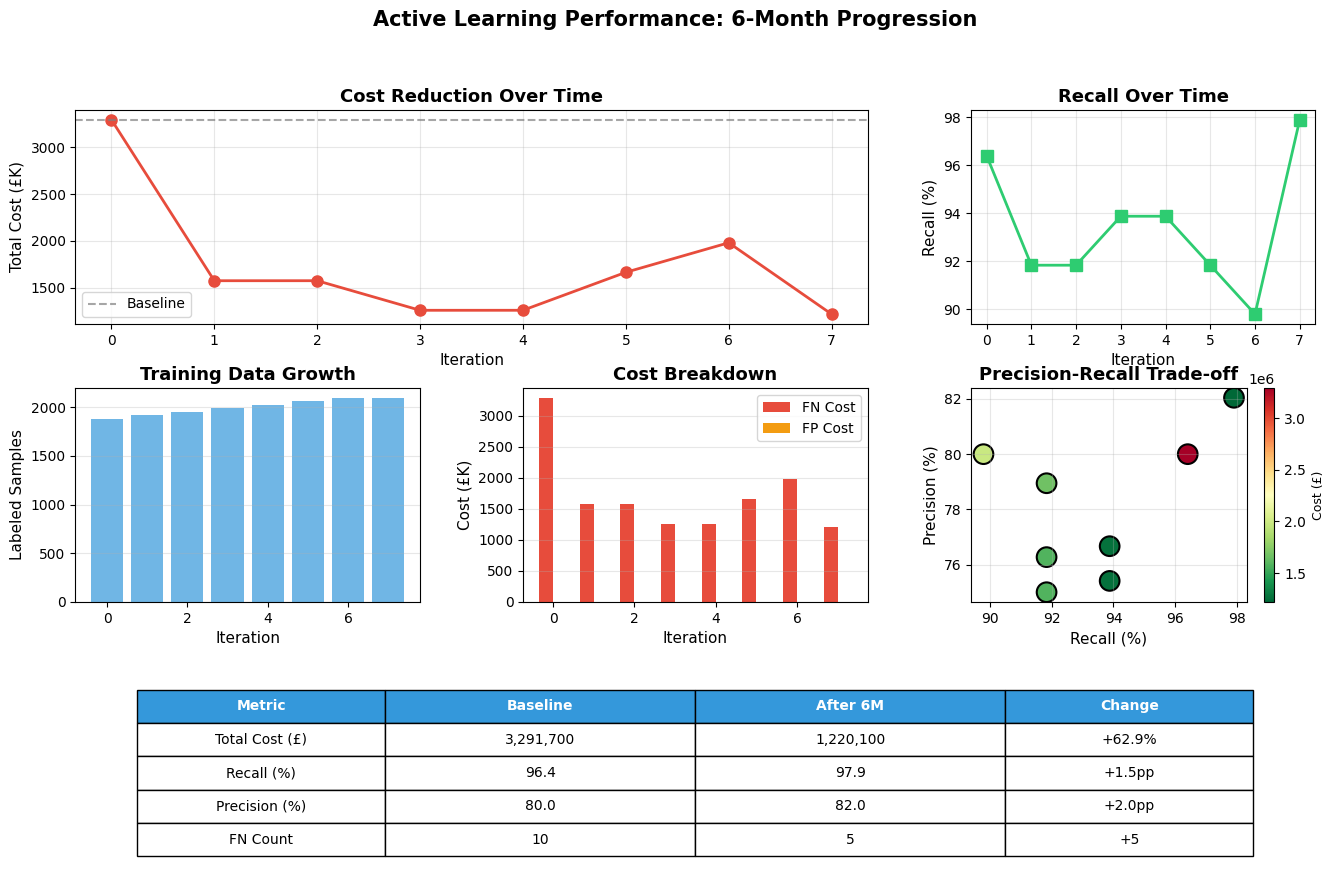


ACTIVE LEARNING WORKFLOW COMPLETE


In [ ]:
# Load universe data
print("Loading universe data...")
df_universe = df.copy()

print(f"Universe size: {len(df_universe)} records")
print(f"Fraud rate: {df_universe['fraud_label'].mean()*100:.2f}%")

# Run Active Learning workflow
al_model, history = run_active_learning_workflow(
    df_universe,
    n_test=5000,
    n_months=6,
    monthly_customers=500
)

print("\n" + "="*100)
print("ACTIVE LEARNING WORKFLOW COMPLETE")
print("="*100)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


# ==================== RULE-BASED SYSTEM ====================

def apply_fraud_rules(df):
    """
    UK Industry-standard fraud detection rules.
    Returns flagged indices based on rule violations.
    """
    flags = pd.Series(False, index=df.index)

    # Calculate derived metrics
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    # RULE 1: High claim ratio + early policyholder (no previous insurance)
    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)

    # RULE 2: Accidental damage + unoccupied + early claim
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)

    # RULE 3: High claim frequency
    flags |= (df['no_of_claims_5yr'] >= 3)

    # RULE 4: Unoccupied + business use + claims
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)

    # RULE 5: Coverage inflation
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)

    # RULE 6: High additional coverage
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)

    # RULE 7: Payment issues + claims
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)

    # RULE 8: Short-term letting + claims
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)

    return flags


# ==================== HELPER FUNCTIONS ====================

def prepare_features(df, categorical_cols=None):
    """Prepare features with one-hot encoding."""
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                          'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Exclude target and metadata columns
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

    return df_encoded[feature_cols]


def calculate_costs(sum_insured, y_true, y_pred):
    """Calculate instance-dependent costs."""
    costs = np.zeros(len(y_true))
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 0:  # FN
            costs[i] = sum_insured[i] * 0.90
        elif y_true[i] == 0 and y_pred[i] == 1:  # FP
            costs[i] = 100
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn_count = np.sum(fn_mask)
    fp_count = np.sum(fp_mask)

    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    precision = tp / (tp + fp_count) if (tp + fp_count) > 0 else 0

    return {
        'total_cost': np.sum(costs),
        'fn_cost': np.sum(costs[fn_mask]),
        'fp_cost': np.sum(costs[fp_mask]),
        'fn_count': fn_count,
        'fp_count': fp_count,
        'tp': tp, 'tn': tn,
        'recall': recall,
        'precision': precision
    }


def find_optimal_threshold(model, X, y, sum_insured):
    """Find cost-minimizing threshold."""
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (proba >= threshold).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_threshold = threshold

    return best_threshold


# ==================== ACTIVE LEARNING PIPELINE ====================

class RealWorldActiveLearning:
    """
    Active Learning as per transcript workflow:
    1. Rule-based filtering on initial customers
    2. Train ML model on investigated (flagged) cases
    3. Monthly/Quarterly: Test on new customers, query uncertain cases
    4. Retrain with expanded labeled set
    5. Track performance improvement over time
    """

    def __init__(self, model_type='xgboost'):
        self.model_type = model_type
        self.model = None
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': [], 'y': [], 'sum_insured': []}
        self.performance_history = []
        self.feature_names = None

    def initialize_model(self):
        """Initialize ML model."""
        if self.model_type == 'xgboost':
            self.model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                scale_pos_weight=5,  # Handle imbalance
                random_state=42,
                eval_metric='logloss'
            )
        else:
            self.model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                class_weight='balanced',
                random_state=42
            )

    def rule_based_filtering(self, df_universe, n_initial=10000):
        """
        Step 1: Take initial customers from universe, apply rules, flag suspicious.
        Returns: flagged indices from universe
        """
        print("="*80)
        print("STEP 1: RULE-BASED FILTERING")
        print("="*80)

        # Sample initial customers
        initial_customers = df_universe.sample(n=min(n_initial, len(df_universe)), random_state=42)

        # Apply fraud rules
        suspicious_flags = apply_fraud_rules(initial_customers)
        flagged_indices = initial_customers[suspicious_flags].index

        print(f"Initial customers: {len(initial_customers)}")
        print(f"Flagged as suspicious: {len(flagged_indices)} ({len(flagged_indices)/len(initial_customers)*100:.1f}%)")

        return flagged_indices, initial_customers.index

    def investigate_and_train(self, df_universe, flagged_indices):
        """
        Step 2: Investigate flagged cases (get true labels from universe).
        Train initial ML model on investigated cases.
        """
        print("\n" + "="*80)
        print("STEP 2: INVESTIGATION & INITIAL MODEL TRAINING")
        print("="*80)

        # Get investigated cases with true labels
        investigated = df_universe.loc[flagged_indices]

        # Prepare features
        X_features = prepare_features(investigated.copy())
        self.feature_names = X_features.columns.tolist()
        X = X_features.values
        y = investigated['fraud_label'].values
        sum_insured = investigated['sum_insured'].values

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Store labeled data
        self.labeled_data['X'] = X_scaled.copy()
        self.labeled_data['y'] = y.copy()
        self.labeled_data['sum_insured'] = sum_insured.copy()

        # Train model
        self.initialize_model()
        self.model.fit(X_scaled, y)

        # Find optimal threshold
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, sum_insured)

        print(f"Investigated cases: {len(flagged_indices)}")
        print(f"Fraud cases found: {y.sum()} ({y.mean()*100:.1f}%)")
        print(f"Initial model trained with {len(X)} samples")
        print(f"Optimal threshold: {self.threshold:.3f}")

        return X_scaled, y, sum_insured

    def test_model(self, df_test):
        """
        Step 3: Test model on new customers.
        Returns predictions and evaluation metrics.
        """
        # Prepare test features
        X_features = prepare_features(df_test.copy())
        # Align features with training
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X_test = X_features.values
        X_test_scaled = self.scaler.transform(X_test)
        y_test = df_test['fraud_label'].values
        sum_test = df_test['sum_insured'].values

        # Predict
        y_proba = self.model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_proba >= self.threshold).astype(int)

        # Evaluate
        results = evaluate_cost_sensitive(y_test, y_pred, sum_test)
        results['y_proba'] = y_proba

        return results

    def query_uncertain_cases(self, df_new, uncertainty_range=(0.2, 0.8), top_n=None):
        """
        FIXED: Query uncertain cases + high-confidence positives for balanced learning.
        """
        # Prepare features
        X_features = prepare_features(df_new.copy())
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X = X_features.values
        X_scaled = self.scaler.transform(X)

        # Get prediction probabilities
        y_proba = self.model.predict_proba(X_scaled)[:, 1]

        # Strategy 1: Uncertain cases (0.2-0.8)
        uncertain_mask = (y_proba >= uncertainty_range[0]) & (y_proba <= uncertainty_range[1])

        # Strategy 2: High-confidence frauds (>0.8) - verify these too
        high_conf_fraud = y_proba > 0.8

        # Strategy 3: Some low-confidence legitimate (<0.2) for balance
        low_conf_legit = y_proba < 0.2

        # Combine: 70% uncertain, 20% high-conf fraud, 10% low-conf legit
        uncertain_idx = df_new[uncertain_mask].index.tolist()
        high_fraud_idx = df_new[high_conf_fraud].index.tolist()
        low_legit_idx = df_new[low_conf_legit].index.tolist()

        if top_n:
            n_uncertain = int(top_n * 0.7)
            n_high = int(top_n * 0.2)
            n_low = top_n - n_uncertain - n_high

            # Sample with cost-weighting
            selected = []

            if len(uncertain_idx) > 0:
                n_sample = min(n_uncertain, len(uncertain_idx))
                weights = df_new.loc[uncertain_idx, 'sum_insured'].values
                weights = weights / weights.sum()
                selected.extend(np.random.choice(uncertain_idx, n_sample, replace=False, p=weights))

            if len(high_fraud_idx) > 0:
                n_sample = min(n_high, len(high_fraud_idx))
                selected.extend(np.random.choice(high_fraud_idx, n_sample, replace=False))

            if len(low_legit_idx) > 0:
                n_sample = min(n_low, len(low_legit_idx))
                selected.extend(np.random.choice(low_legit_idx, n_sample, replace=False))

            uncertain_indices = selected
        else:
            uncertain_indices = uncertain_idx + high_fraud_idx[:20] + low_legit_idx[:10]

        return uncertain_indices

    def retrain_with_new_labels(self, df_universe, new_labeled_indices):
        """
        FIXED: Add new labels but maintain stable threshold.
        """
        # Get new labeled data
        new_data = df_universe.loc[new_labeled_indices]
        X_features = prepare_features(new_data.copy())
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X_new = X_features.values
        X_new_scaled = self.scaler.transform(X_new)
        y_new = new_data['fraud_label'].values
        sum_new = new_data['sum_insured'].values

        # Append to labeled data
        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new_scaled])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], sum_new])

        # Retrain model
        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])

        # FIXED: Only update threshold if significant improvement (>5% cost reduction)
        old_threshold = self.threshold
        new_threshold = find_optimal_threshold(
            self.model,
            self.labeled_data['X'],
            self.labeled_data['y'],
            self.labeled_data['sum_insured']
        )

        # Test both thresholds on training data
        y_proba = self.model.predict_proba(self.labeled_data['X'])[:, 1]

        cost_old = np.sum(calculate_costs(
            self.labeled_data['sum_insured'],
            self.labeled_data['y'],
            (y_proba >= old_threshold).astype(int)
        ))

        cost_new = np.sum(calculate_costs(
            self.labeled_data['sum_insured'],
            self.labeled_data['y'],
            (y_proba >= new_threshold).astype(int)
        ))

        # Only update if >5% improvement
        if cost_new < cost_old * 0.95:
            self.threshold = new_threshold

        return len(self.labeled_data['y'])


# ==================== COMPLETE WORKFLOW ====================

def run_active_learning_workflow(df_universe, n_initial=20000, n_test=5000,
                                 n_months=6, monthly_customers=1000, query_budget=200):
    """
    SCALABLE Active Learning workflow.

    Parameters:
    - df_universe: Full dataset (universe)
    - n_initial: Initial customers for rule-based filtering (10K, 20K, or 50K)
    - n_test: Test set size (default 5K)
    - n_months: Number of months to simulate (default 6)
    - monthly_customers: New customers per month (scale with n_initial)
    - query_budget: Cases to investigate per month (scale with monthly_customers)

    Recommended configurations:
    - Small: n_initial=10K, monthly=500, query=100
    - Medium: n_initial=20K, monthly=1000, query=200
    - Large: n_initial=50K, monthly=2000, query=400
    """

    print("\n" + "="*100)
    print(" "*30 + "ACTIVE LEARNING WORKFLOW")
    print("="*100)
    print(f"Configuration: Initial={n_initial:,}, Monthly={monthly_customers:,}, Query/Month={query_budget}")
    print("="*100)

    al = RealWorldActiveLearning(model_type='xgboost')

    # Track used indices
    used_indices = set()

    # ==================== STEP 1 & 2: RULE-BASED + INITIAL TRAINING ====================
    flagged_idx, initial_idx = al.rule_based_filtering(df_universe, n_initial=n_initial)
    used_indices.update(initial_idx)

    X_train, y_train, sum_train = al.investigate_and_train(df_universe, flagged_idx)

    # ==================== STEP 3: INITIAL TEST (BASELINE) ====================
    print("\n" + "="*80)
    print("STEP 3: BASELINE TEST (Before Active Learning)")
    print("="*80)

    available_test = df_universe.drop(index=used_indices)
    test_baseline = available_test.sample(n=min(n_test, len(available_test)), random_state=42)
    used_indices.update(test_baseline.index)

    results_baseline = al.test_model(test_baseline)

    print(f"Test samples: {len(test_baseline)}")
    print(f"Total Cost: £{results_baseline['total_cost']:,.0f}")
    print(f"Recall: {results_baseline['recall']*100:.1f}%")
    print(f"Precision: {results_baseline['precision']*100:.1f}%")

    al.performance_history.append({
        'iteration': 0,
        'month': 'Baseline',
        'labeled_count': len(al.labeled_data['y']),
        **results_baseline
    })

    # ==================== STEP 4: MONTHLY ACTIVE LEARNING LOOP ====================
    print("\n" + "="*80)
    print("STEP 4: ACTIVE LEARNING - MONTHLY ITERATIONS")
    print("="*80)

    # Fixed test set for consistent monthly evaluation
    available_monthly_test = df_universe.drop(index=used_indices)
    monthly_test_set = available_monthly_test.sample(n=min(n_test, len(available_monthly_test)), random_state=999)
    used_indices.update(monthly_test_set.index)

    for month in range(1, n_months + 1):
        print(f"\n--- Month {month} ---")

        # New customers arrive
        available = df_universe.drop(index=used_indices)
        if len(available) < monthly_customers:
            print(f"Insufficient data remaining. Stopping at month {month-1}.")
            break

        new_customers = available.sample(n=monthly_customers, random_state=42+month)
        used_indices.update(new_customers.index)

        # Query uncertain cases (70% uncertain, 20% high-conf, 10% low-conf)
        uncertain_idx = al.query_uncertain_cases(new_customers, uncertainty_range=(0.2, 0.8), top_n=query_budget)

        print(f"New customers: {len(new_customers)}")
        print(f"Cases queried for investigation: {len(uncertain_idx)}")

        # Investigate and retrain
        if len(uncertain_idx) > 0:
            new_labeled_count = al.retrain_with_new_labels(df_universe, uncertain_idx)
            print(f"Total labeled data: {new_labeled_count}")
            print(f"Threshold: {al.threshold:.3f}")

        # FIXED: Test on consistent held-out test set (not remaining customers)
        results_month = al.test_model(monthly_test_set)
        print(f"Monthly test cost (fixed test set): £{results_month['total_cost']:,.0f}")

        al.performance_history.append({
            'iteration': month,
            'month': f'Month {month}',
            'labeled_count': len(al.labeled_data['y']),
            **results_month
        })

    # ==================== STEP 5: FINAL TEST (SHOW IMPROVEMENT) ====================
    print("\n" + "="*80)
    print("STEP 5: FINAL TEST (After Active Learning)")
    print("="*80)

    available_final = df_universe.drop(index=used_indices)
    test_final = available_final.sample(n=min(n_test, len(available_final)), random_state=99)

    results_final = al.test_model(test_final)

    print(f"Test samples: {len(test_final)}")
    print(f"Total Cost: £{results_final['total_cost']:,.0f}")
    print(f"Recall: {results_final['recall']*100:.1f}%")
    print(f"Precision: {results_final['precision']*100:.1f}%")

    al.performance_history.append({
        'iteration': n_months + 1,
        'month': 'Final Test',
        'labeled_count': len(al.labeled_data['y']),
        **results_final
    })

    # ==================== RESULTS SUMMARY ====================
    print("\n" + "="*100)
    print("PERFORMANCE IMPROVEMENT SUMMARY")
    print("="*100)

    history_df = pd.DataFrame(al.performance_history)

    print(f"\nBaseline (Initial Model):")
    print(f"  Cost: £{results_baseline['total_cost']:,.0f}")
    print(f"  Recall: {results_baseline['recall']*100:.1f}%")
    print(f"  Training Data: {len(flagged_idx)} samples")

    print(f"\nFinal (After {n_months} months AL):")
    print(f"  Cost: £{results_final['total_cost']:,.0f}")
    print(f"  Recall: {results_final['recall']*100:.1f}%")
    print(f"  Training Data: {len(al.labeled_data['y'])} samples (+{len(al.labeled_data['y']) - len(flagged_idx)})")

    cost_improvement = (results_baseline['total_cost'] - results_final['total_cost']) / results_baseline['total_cost'] * 100
    recall_improvement = (results_final['recall'] - results_baseline['recall']) * 100

    print(f"\nImprovement:")
    print(f"  Cost Reduction: {cost_improvement:+.1f}%")
    print(f"  Recall Gain: {recall_improvement:+.1f} percentage points")
    print(f"  Data Efficiency: {len(al.labeled_data['y'])/n_initial*100:.1f}% of initial pool used")

    # ==================== VISUALIZATION ====================
    visualize_results(history_df, results_baseline, results_final, n_months)

    return al, history_df


def visualize_results(history_df, baseline, final, n_months):
    """Create comprehensive visualization."""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Cost over time
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(history_df['iteration'], history_df['total_cost']/1000,
             marker='o', linewidth=2, markersize=8, color='#e74c3c')
    ax1.axhline(y=baseline['total_cost']/1000, color='gray', linestyle='--', label='Baseline', alpha=0.7)
    ax1.set_xlabel('Iteration', fontsize=11)
    ax1.set_ylabel('Total Cost (£K)', fontsize=11)
    ax1.set_title('Cost Reduction Over Time', fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend()

    # 2. Recall improvement
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(history_df['iteration'], history_df['recall']*100,
             marker='s', linewidth=2, markersize=8, color='#2ecc71')
    ax2.set_xlabel('Iteration', fontsize=11)
    ax2.set_ylabel('Recall (%)', fontsize=11)
    ax2.set_title('Recall Over Time', fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3)

    # 3. Labeled data growth
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.bar(history_df['iteration'], history_df['labeled_count'], color='#3498db', alpha=0.7)
    ax3.set_xlabel('Iteration', fontsize=11)
    ax3.set_ylabel('Labeled Samples', fontsize=11)
    ax3.set_title('Training Data Growth', fontsize=13, fontweight='bold')
    ax3.grid(alpha=0.3, axis='y')

    # 4. FN vs FP cost
    ax4 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(history_df))
    width = 0.35
    ax4.bar(x - width/2, history_df['fn_cost']/1000, width, label='FN Cost', color='#e74c3c')
    ax4.bar(x + width/2, history_df['fp_cost']/1000, width, label='FP Cost', color='#f39c12')
    ax4.set_xlabel('Iteration', fontsize=11)
    ax4.set_ylabel('Cost (£K)', fontsize=11)
    ax4.set_title('Cost Breakdown', fontsize=13, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3, axis='y')

    # 5. Precision vs Recall
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(history_df['recall']*100, history_df['precision']*100,
               s=200, c=history_df['total_cost'], cmap='RdYlGn_r',
               edgecolors='black', linewidth=1.5)
    ax5.set_xlabel('Recall (%)', fontsize=11)
    ax5.set_ylabel('Precision (%)', fontsize=11)
    ax5.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
    ax5.grid(alpha=0.3)
    cbar = plt.colorbar(ax5.collections[0], ax=ax5)
    cbar.set_label('Cost (£)', fontsize=9)

    # 6. Summary metrics table
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('off')

    summary_data = [
        ['Metric', 'Baseline', f'After {n_months}M', 'Change'],
        ['Total Cost (£)', f'{baseline["total_cost"]:,.0f}', f'{final["total_cost"]:,.0f}',
         f'{(baseline["total_cost"]-final["total_cost"])/baseline["total_cost"]*100:+.1f}%'],
        ['Recall (%)', f'{baseline["recall"]*100:.1f}', f'{final["recall"]*100:.1f}',
         f'{(final["recall"]-baseline["recall"])*100:+.1f}pp'],
        ['Precision (%)', f'{baseline["precision"]*100:.1f}', f'{final["precision"]*100:.1f}',
         f'{(final["precision"]-baseline["precision"])*100:+.1f}pp'],
        ['FN Count', f'{baseline["fn_count"]}', f'{final["fn_count"]}',
         f'{int(baseline["fn_count"]-final["fn_count"]):+d}'],
    ]

    table = ax6.table(cellText=summary_data, cellLoc='center', loc='center',
                     colWidths=[0.2, 0.25, 0.25, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.suptitle(f'Active Learning Performance: {n_months}-Month Progression',
                fontsize=15, fontweight='bold', y=0.98)

    plt.show()

Loading universe data...
Universe size: 500000 records
Fraud rate: 5.03%

SCALABLE ACTIVE LEARNING CONFIGURATIONS

                              ACTIVE LEARNING WORKFLOW
Configuration: Initial=10,000, Monthly=500, Query/Month=100
STEP 1: RULE-BASED FILTERING
Initial customers: 10000
Flagged as suspicious: 1880 (18.8%)

STEP 2: INVESTIGATION & INITIAL MODEL TRAINING
Investigated cases: 1880
Fraud cases found: 380 (20.2%)
Initial model trained with 1880 samples
Optimal threshold: 0.296

STEP 3: BASELINE TEST (Before Active Learning)
Test samples: 5000
Total Cost: £3,291,700
Recall: 96.4%
Precision: 80.0%

STEP 4: ACTIVE LEARNING - MONTHLY ITERATIONS

--- Month 1 ---
New customers: 500
Cases queried for investigation: 38
Total labeled data: 1918
Threshold: 0.476
Monthly test cost (fixed test set): £6,619,300

--- Month 2 ---
New customers: 500
Cases queried for investigation: 41
Total labeled data: 1959
Threshold: 0.476
Monthly test cost (fixed test set): £4,774,600

--- Month 3 ---
New c

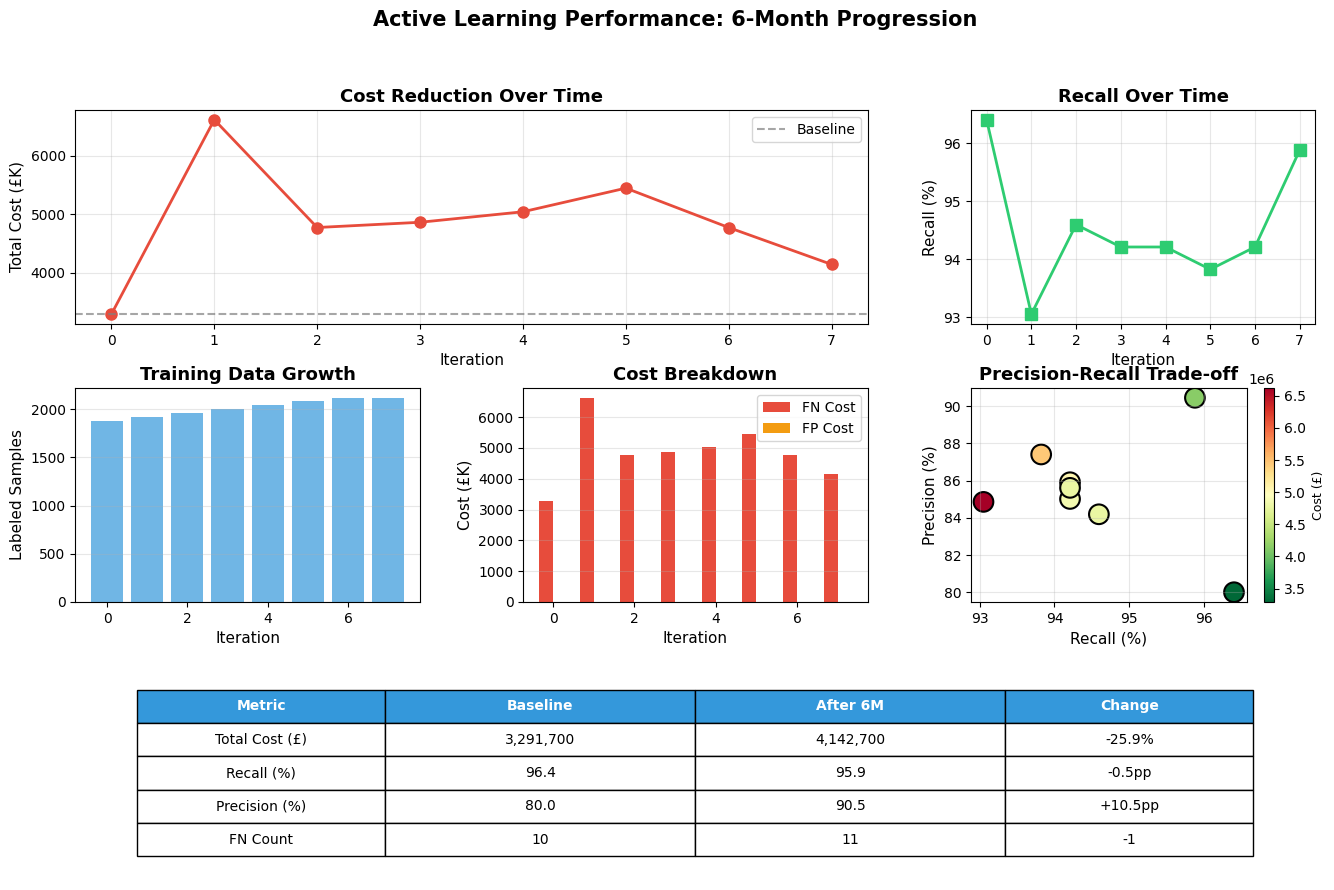


ACTIVE LEARNING WORKFLOW COMPLETE

Results saved to 'active_learning_results.csv'

DATA USAGE SUMMARY
Initial training data: 1,880 samples
Final training data: 2,114 samples
New data added via AL: 234 samples
Percentage of universe used: 0.42%


In [ ]:
print("Loading universe data...")
df_universe = df.copy()

print(f"Universe size: {len(df_universe)} records")
print(f"Fraud rate: {df_universe['fraud_label'].mean()*100:.2f}%")

# ==================== CONFIGURATION OPTIONS ====================
print("\n" + "="*80)
print("SCALABLE ACTIVE LEARNING CONFIGURATIONS")
print("="*80)

# Choose configuration based on your needs:

# SMALL SCALE (10K initial, good for testing)
al_model, history = run_active_learning_workflow(
    df_universe,
    n_initial=10000,
    n_test=5000,
    n_months=6,
    monthly_customers=500,
    query_budget=100
)

# # MEDIUM SCALE (20K initial, balanced)
# al_model, history = run_active_learning_workflow(
#     df_universe,
#     n_initial=20000,
#     n_test=5000,
#     n_months=6,
#     monthly_customers=1000,
#     query_budget=200
# )

# LARGE SCALE (50K initial, comprehensive)
# al_model, history = run_active_learning_workflow(
#     df_universe,
#     n_initial=50000,
#     n_test=10000,
#     n_months=12,
#     monthly_customers=2000,
#     query_budget=400
# )

print("\n" + "="*100)
print("ACTIVE LEARNING WORKFLOW COMPLETE")
print("="*100)

# Export results
history.to_csv('active_learning_results.csv', index=False)
print("\nResults saved to 'active_learning_results.csv'")

# Print data usage summary
print("\n" + "="*80)
print("DATA USAGE SUMMARY")
print("="*80)
total_used = history.iloc[-1]['labeled_count']
initial_used = history.iloc[0]['labeled_count']
print(f"Initial training data: {initial_used:,} samples")
print(f"Final training data: {total_used:,} samples")
print(f"New data added via AL: {total_used - initial_used:,} samples")
print(f"Percentage of universe used: {total_used/len(df_universe)*100:.2f}%")